In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
from src import (
    load_simple_price_csv,
    VectorizedEngine,
    FixedRiskPositionStrategy,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-08-03 11:30:34.001 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-08-03 11:30:34.014 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [43]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MULTIPLIER=1.0
MAX_LEVERAGE=10
COMMISSION_RATE=0.0005
SLIPPAGE_RATE=0.0005

In [44]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=COMMISSION_RATE,
    slippage_rate=SLIPPAGE_RATE
)

In [45]:
strategy = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE, max_capital_loss = 1, expected_worst_return = 0.001)

In [46]:
result = engine.run(strategy, data)


[DEBUG] Day 252:
  Capital: 100,000
  Price: 600.29
  Volatility (σ): 0.3108 (Should be ~0.15 for 15%)
  Risk Target (τ): 0.20
  Effective Risk: 0.20
  Raw N_contracts: 107.19
  Max Leverage: 10x
  Max N_contracts: 1,665.86
  Final N_contracts: 107.19

[DEBUG] Day 504:
  Capital: 100,000
  Price: 606.21
  Volatility (σ): 0.3352 (Should be ~0.15 for 15%)
  Risk Target (τ): 0.20
  Effective Risk: 0.20
  Raw N_contracts: 98.42
  Max Leverage: 10x
  Max N_contracts: 1,649.59
  Final N_contracts: 98.42

[DEBUG] Day 756:
  Capital: 100,000
  Price: 1,274.83
  Volatility (σ): 0.2781 (Should be ~0.15 for 15%)
  Risk Target (τ): 0.20
  Effective Risk: 0.20
  Raw N_contracts: 56.41
  Max Leverage: 10x
  Max N_contracts: 784.42
  Final N_contracts: 56.41

[DEBUG] Day 1008:
  Capital: 100,000
  Price: 1,677.81
  Volatility (σ): 0.3677 (Should be ~0.15 for 15%)
  Risk Target (τ): 0.20
  Effective Risk: 0.20
  Raw N_contracts: 32.42
  Max Leverage: 10x
  Max N_contracts: 596.02
  Final N_contracts:

In [47]:
result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +6.3% │
│ Average drawdown                         │                    -1.6% │
│ Maximum drawdown                         │                   -23.9% │
│ Annualised standard deviation            │                    10.5% │
│ Sharpe ratio                             │                     0.60 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     2.06 │
│ Upper tail                               │                     1.70 │
└──────────────────────────────────────────────────────────────────────┘


c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


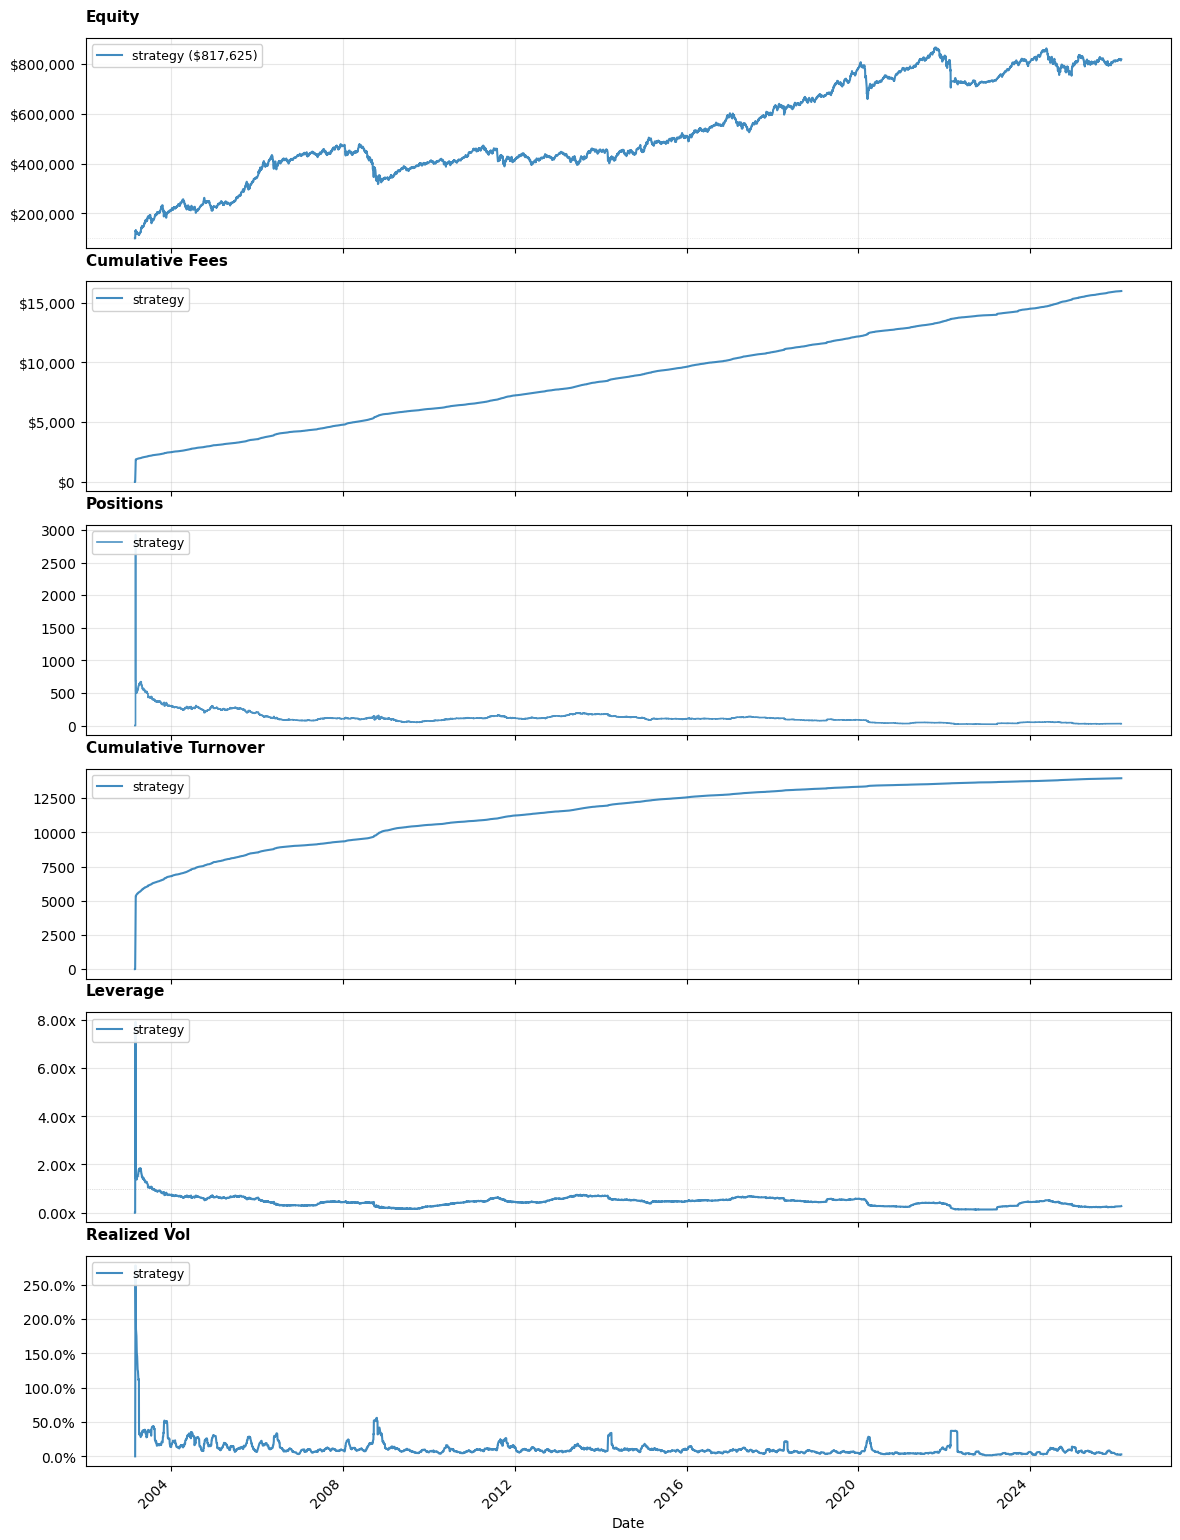

In [42]:
plot_backtest_results(
    results={"strategy": result},
    panels=['equity', 'cumulative_fees', 'positions','cumulative_turnover', 'leverage', "realized_vol"],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)